In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import MDAnalysis as mda
from MDAnalysis.analysis import rdf
import time

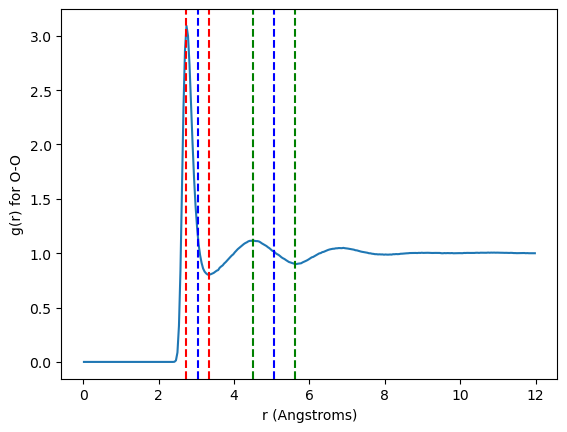

Time Taken=32.745seconds


In [2]:
"""
1st task: Compute the RDF, find the first two peaks and valleys
To find the peaks, first see the rdf to estimate a rough position of the first peak
Also, the O_list is for storing the time dependent positions, and the box_list is for storing the time-dependent box dimensions
"""
s1=time.time()
u=mda.Universe("system.data", "Water.lammpstrj", format="LAMMPSDUMP", dt=0.5, atom_style="id mol type q x y z")
Water=u.atoms
Oxy=u.select_atoms("type 1")
Hydro=u.select_atoms("type 2")
O_rdf=rdf.InterRDF(Oxy, Oxy, nbins=300, range=(0.0, 12.0), exclusion_block=(1, 1))
O_rdf.run(start=2000)

n_frames=len(u.trajectory)
n_atoms=len(Water)
n_water=n_atoms//3
eq_frames=2000
prod_frames=n_frames-eq_frames

O_list=[]
box_list=[]

for ts in u.trajectory[eq_frames:]:
    O_list.append(Oxy.positions.copy())
    box_list.append(ts.dimensions[:3])

O_coords=np.array(O_list)
box_coords=np.array(box_list)

r_O=O_rdf.results.bins
g_r_O=O_rdf.results.rdf

max1_ind=np.argmax(g_r_O[:75])
min1_ind=np.argmin(g_r_O[max1_ind:(max1_ind+40)])+max1_ind
r_max1=r_O[max1_ind]
r_min1=r_O[min1_ind]

max2_ind=np.argmax(g_r_O[min1_ind:min1_ind+40])+min1_ind
min2_ind=np.argmin(g_r_O[max2_ind:max2_ind+40])+max2_ind
r_max2=r_O[max2_ind]
r_min2=r_O[min2_ind]

r_mid1=0.5*(r_max1+r_min1)
r_mid2=0.5*(r_max2+r_min2)

plt.plot(r_O, g_r_O, label="O-O RDF")
plt.axvline(r_max1, color="red", linestyle="--")
plt.axvline(r_min1, color="red", linestyle="--")
plt.axvline(r_max2, color="green", linestyle="--")
plt.axvline(r_min2, color="green", linestyle="--")
plt.axvline(r_mid1, color="blue", linestyle="--")
plt.axvline(r_mid2, color="blue", linestyle="--")
plt.xlabel("r (Angstroms)")
plt.ylabel("g(r) for O-O")
plt.show()

#print(n_frames)
e1=time.time()
t1=e1-s1
print(f"Time Taken={t1:.3f}seconds")

Calcs for Block0
Calcs for Block1
Calcs for Block2
Calcs for Block3
Calcs for Block4
Mean Residence Time=3.099ps


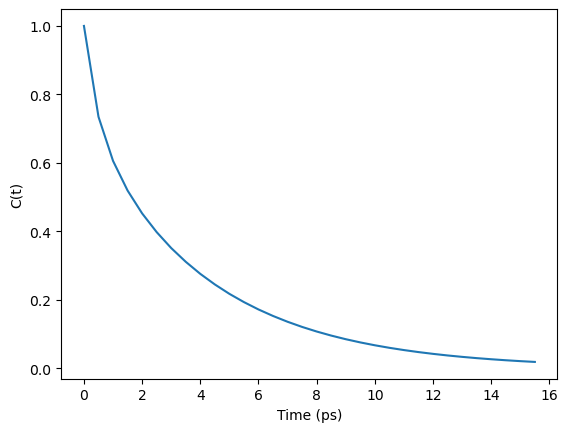

Time Taken=639.122seconds


In [ ]:
"""
Task2: Find the time correlation function (Here, the unit of time is fs only, NOT ps). From now onwards, the frames which matter are prod_frames only
tlag: A new variable: What's the role of this variable? Sampling! Suppose that the time goes from 0 to 15, and maxlag_time=5. If we try to sample every time step, we'll have 11 t_origins (tlag~1), but if we set tlag=2, our t_origins would be 0, 2, 4, 6, 8, 10
"""
s2=time.time()
in_shell=r_mid1
out_shell=r_mid2
dump_freq=1000
delt=0.5
dt=dump_freq*delt
n_blocks=5
traj_frac=0.04
n_framesperblock=prod_frames//n_blocks
maxlag_time=int(n_framesperblock*dt*traj_frac)
maxlag_steps=int(maxlag_time/dt)
tlag=1000
n_origins=int((n_framesperblock*dt-maxlag_time)/tlag)

rtd=np.zeros((n_blocks, n_water, maxlag_steps))
Time=np.arange(0, maxlag_steps)*dt/1000  #t in ps

for nb in range (n_blocks):
    print(f"Calcs for Block{nb}")
    O_block=O_coords[nb*n_framesperblock: (nb+1)*n_framesperblock] #For the O_block, there are 3 sizes, first corresponds to the frame number, second corresponds to the atom number, and third corresponds to the direction (3 directions: x, y, and z)
    box_block=box_coords[nb*n_framesperblock: (nb+1)*n_framesperblock]

    for i in range(n_origins):
        start=int(i*tlag/dt) #starting frame
        diff0=O_block[start, :, np.newaxis, :]-O_block[start, np.newaxis, :, :] #What do you think about the size of the delta r array? (#time-steps)*(#atoms)*(#atoms)*(3), that's why we've np.newaxis at these positions
        diff0-=np.round(diff0/box_block[start])*box_block[start] #It's not a 4D array anymore, because one index has been fixed!
        dist0=np.linalg.norm(diff0, axis=2) #axis=2 represents the coordinates only :) We'll get a 2D array after applying the norm

        v0_mask=(dist0<3.85)&(dist0>0.01) #Avoid self counting, and do a bit-wise "and", normal "and" won't work! This is for comparing every element of the array to 3.85 and 0.01
        escaped_mask=np.zeros((n_water, n_water), dtype=bool)

        for j in range(maxlag_steps):
            curr=start+j
            diff_t=O_block[curr, :, np.newaxis, :]-O_block[curr, np.newaxis, :, :]
            diff_t-=np.round(diff_t/box_block[curr])*box_block[curr]
            dist_t=np.linalg.norm(diff_t, axis=2)
            escaped_mask|=(dist_t>3.85)
        
            for water in range(n_water):
                n_init=np.sum(v0_mask[water])
                if(n_init>0):
                    n_escaped=np.sum(v0_mask[water]&escaped_mask[water])
                    rtd[nb, water, j]+=(1-n_escaped/n_init)

rtd_survival=rtd/n_origins
rtd_ave=np.mean(rtd_survival, axis=1)
rtd_final=np.mean(rtd_ave, axis=0)

tau=np.trapezoid(rtd_final, Time)

print(f"Mean Residence Time={tau:.3f}ps")

plt.plot(Time, rtd_final)
plt.xlabel("Time (ps)")
plt.ylabel("C(t)")
plt.show()

e2=time.time()
t2=e2-s2
print(f"Time Taken={t2:.3f}seconds")

In [4]:
print(O_coords.shape)

(4001, 500, 3)
